In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import torchvision.transforms as tvf

from unicorrn.model import build_model
from unicorrn.utils import safe_load_weights
from unicorrn.utils.config import read_yaml_config
from fvcore.nn import parameter_count

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
xFormers is available.
Flash attention is not available
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/projects/vig/prajnan/envs/unicorrn/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
MODEL_CONFIG_PATH="../configs/models/unicorrn_large_stage2.yml"
CKPT_PATH="../pretrained_models/UniCorrn_Large_Stage2.pth"

model_cfg = read_yaml_config(MODEL_CONFIG_PATH)

model = build_model(model_cfg.NAME, cfg=model_cfg)
print(f"Model params: {parameter_count(model)[''] / 1e6:.1f}M")

weights = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
safe_load_weights(model, weights["model"])

Model params: 599.8M
weights safely loaded


In [3]:
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    
    return tensor * std + mean
    

def from_numpy(x):
    if isinstance(x, np.ndarray):
        # 0-d object arrays = nested dicts/lists/strings/scalars saved via pickle
        if x.dtype == object:
            return from_numpy(x.item())
        # 0-d numeric arrays = scalars; unwrap to Python number
        if x.ndim == 0:
            return x.item()
        # numeric ndarray -> tensor (skip dtypes torch can't handle)
        if x.dtype.kind in ("b", "i", "u", "f", "c"):
            return torch.from_numpy(x.copy())
        return x  # e.g. string arrays
    if isinstance(x, dict):
        return {k: from_numpy(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return type(x)(from_numpy(v) for v in x)
    return x


with np.load("../assets/2d3d_sample.npz", allow_pickle=True) as npz:
    sample = {k: from_numpy(npz[k]) for k in npz.files}

sample.keys()

dict_keys(['points', 'min_grid_coord', 'image_w', 'image_h', 'intrinsics', 'depth_file', 'transform', 'grid_coord', 'scene_name', 'points_norm_meta', 'overlap', 'cloud_id', 'image_file', 'image_id', 'cloud_file', 'dataset', 'lengths', 'image', 'depth', 'batch_size', 'queries', 'targets', 'norm_queries', 'norm_targets'])

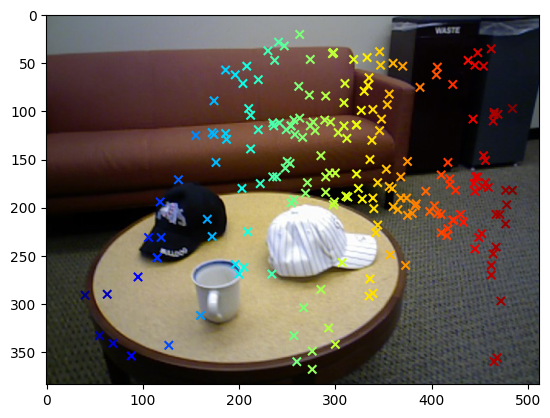

In [4]:
plt.imshow(denormalize(sample["image"].squeeze()).permute(1,2,0).numpy())
stride = 1
queries = sample["queries"]
x = queries[:,::stride][...,0]
y = queries[:,::stride][...,1]
plt.scatter(x, y, c=x, cmap='jet', marker='x')

In [5]:
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        sample[k] = v.cuda()

model.eval()
model = model.cuda()

In [6]:
with torch.no_grad():
    preds = model.forward_img_to_pcd(
        src_img=sample["image"], sample=sample, query_pos_2d=sample["queries"]
    )["img2pcd"]

In [ ]:
points = sample["points"].cpu()
targets = sample["norm_targets"].squeeze().cpu()
target_preds = preds["corr_predictions"].squeeze().cpu()

pcd = go.Scatter3d(
    x=points[...,0],
    y=points[...,1],
    z=points[...,2],
    mode='markers',
    name="source pcd",
    marker=dict(
        size=1.0,
        color=points[...,2],        # color by z value
        colorscale='Blues_r',
        opacity=0.8
    )
)

stride = 1
kpts_gt = go.Scatter3d(
    x=targets[::stride][..., 0],
    y=targets[::stride][..., 1],
    z=targets[::stride][..., 2],
    mode='markers',
    name="target_gt",
    marker=dict(
        size=3,
        color=targets[::stride][...,0],        # color by x value
        colorscale='jet',
        opacity=0.8,
        symbol='x'
    )
)

kpts_pred = go.Scatter3d(
    x=target_preds[::stride][..., 0],
    y=target_preds[::stride][..., 1],
    z=target_preds[::stride][..., 2],
    mode='markers',
    name="target_pred",
    marker=dict(
        size=5,
        color=targets[::stride][...,0],        # color by x value
        colorscale='jet',
        opacity=1.0,
        # symbol='x'
    )
)

fig = go.Figure(data=[pcd, kpts_gt, kpts_pred])

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='black',
    ),
    paper_bgcolor='black',
    legend=dict(
        x=0,
        y=1,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.6)',
        font=dict(color='black'),
    ),
    margin=dict(l=0, r=0, b=0, t=0),
)
fig.show()